In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time

In [2]:
df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_f.csv')

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_71924/1921982114.py:1: DtypeWarning: Columns (0: MAIL_ZIP_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_f.csv')


In [3]:
# Cell 2 — data prep + split (this was deleted)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')   # fix leaky row index

X = df.drop(columns=['TOTAL_VALUE'])
y = df['TOTAL_VALUE']

# Encode categoricals
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Single split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_71924/40760741.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


Training Linear Regression...
  R²(log)=0.7013  R²(orig)=0.0837  RMSE(orig)=12,344,585
Training Ridge...
  R²(log)=0.7013  R²(orig)=0.0837  RMSE(orig)=12,344,584
Training Lasso...
  R²(log)=0.7012  R²(orig)=0.0848  RMSE(orig)=12,336,625
Training Decision Tree...
  R²(log)=0.8933  R²(orig)=0.4399  RMSE(orig)=9,651,032
Training KNN...
  R²(log)=0.5660  R²(orig)=0.0925  RMSE(orig)=12,284,531
Training Random Forest...
  R²(log)=0.9385  R²(orig)=0.7473  RMSE(orig)=6,482,752
Training Extra Trees...
  R²(log)=0.9424  R²(orig)=0.7900  RMSE(orig)=5,909,518
Training Gradient Boosting...
  R²(log)=0.9268  R²(orig)=0.7836  RMSE(orig)=5,999,233
Training XGBoost...
  R²(log)=0.9404  R²(orig)=0.7588  RMSE(orig)=6,332,873
Training Ensemble (RF+XGB+ET)...
  R²(log)=0.9435  R²(orig)=0.8063  RMSE(orig)=5,675,450

                   Model    R2_log  RMSE_log   R2_orig     RMSE_orig
0  Ensemble (RF+XGB+ET)  0.943458  0.280928  0.806310  5.675450e+06
1           Extra Trees  0.942409  0.283522  0.790004  5.

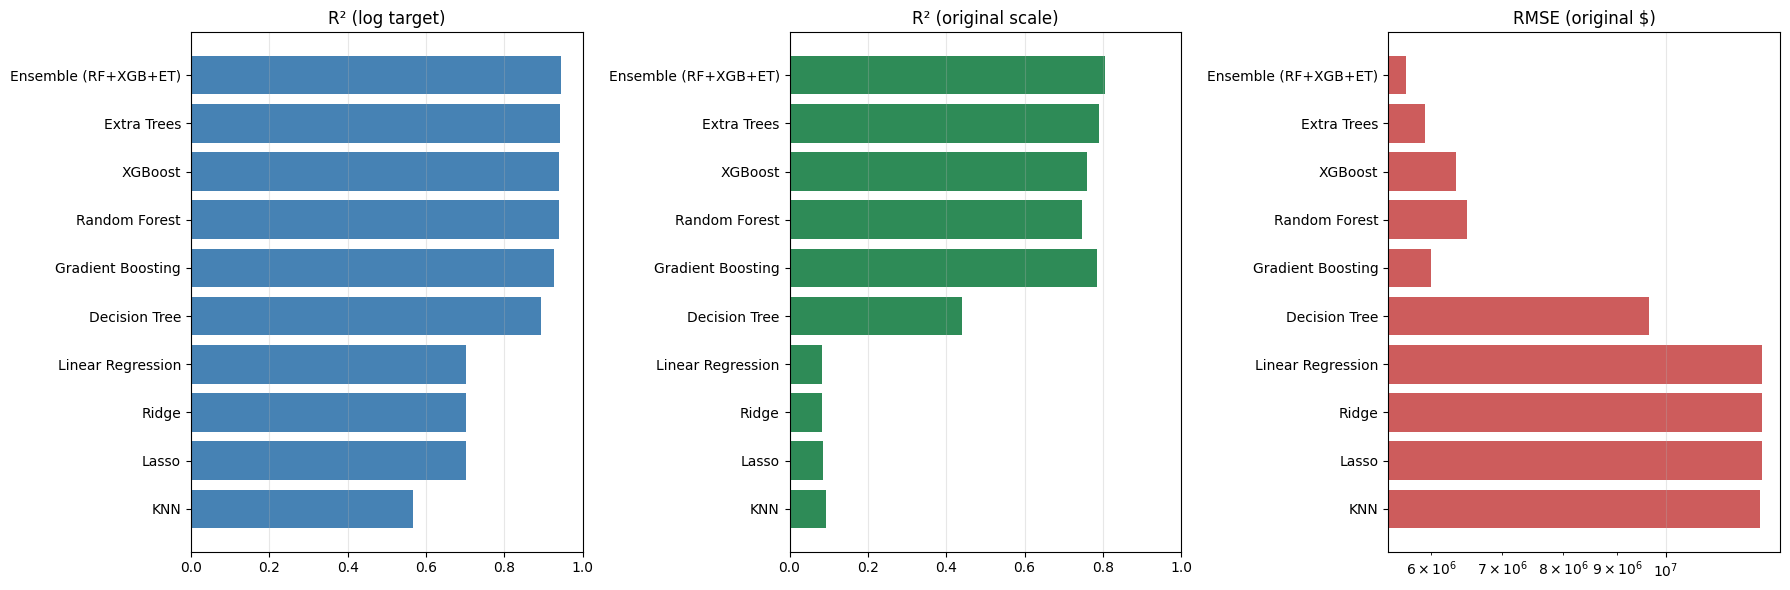

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

# Assumes X_train, X_test, y_train, y_test already exist (log-transformed target)

def make_models():
    """Factory so we don't hold all instances in memory at once."""
    return {
        'Linear Regression': lambda: LinearRegression(n_jobs=-1),
        'Ridge': lambda: Ridge(alpha=1.0, random_state=42),
        'Lasso': lambda: Lasso(alpha=0.001, random_state=42, max_iter=5000),
        'Decision Tree': lambda: DecisionTreeRegressor(max_depth=15, random_state=42),
        'KNN': lambda: KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
        'Random Forest': lambda: RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1),
        'Extra Trees': lambda: ExtraTreesRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1),
        'Gradient Boosting': lambda: GradientBoostingRegressor(n_estimators=150, max_depth=5, random_state=42),
        'XGBoost': lambda: XGBRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=8,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0, tree_method='hist'
        ),
        'Ensemble (RF+XGB+ET)': lambda: VotingRegressor([
            ('rf',  RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)),
            ('xgb', XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=8,
                                 random_state=42, n_jobs=-1, verbosity=0, tree_method='hist')),
            ('et',  ExtraTreesRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)),
        ], n_jobs=1),  # n_jobs=1 here — each inner model already parallel
    }

results = []
# at the end of cell 3, replace the existing for-loop with this one:
for name, factory in make_models().items():
    print(f"Training {name}...", flush=True)
    model = factory()
    model.fit(X_train, y_train_log)                                   # ← log target
    pred_log = model.predict(X_test)

    r2_log    = r2_score(y_test_log, pred_log)
    rmse_log  = np.sqrt(mean_squared_error(y_test_log, pred_log))
    r2_orig   = r2_score(y_test, np.expm1(pred_log))                  # y_test is already original
    rmse_orig = np.sqrt(mean_squared_error(y_test, np.expm1(pred_log)))

    results.append({'Model': name, 'R2_log': r2_log, 'RMSE_log': rmse_log,
                    'R2_orig': r2_orig, 'RMSE_orig': rmse_orig})
    print(f"  R²(log)={r2_log:.4f}  R²(orig)={r2_orig:.4f}  RMSE(orig)={rmse_orig:,.0f}")
    del model, pred_log; gc.collect()

results_df = pd.DataFrame(results).sort_values('R2_log', ascending=False).reset_index(drop=True)
print("\n", results_df)

# --- comparison plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ordered = results_df.sort_values('R2_log')

axes[0].barh(ordered['Model'], ordered['R2_log'], color='steelblue')
axes[0].set_title('R² (log target)'); axes[0].set_xlim(0, 1); axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(ordered['Model'], ordered['R2_orig'], color='seagreen')
axes[1].set_title('R² (original scale)'); axes[1].set_xlim(0, 1); axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(ordered['Model'], ordered['RMSE_orig'], color='indianred')
axes[2].set_title('RMSE (original $)'); axes[2].set_xscale('log'); axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

In [4]:
"""
Optuna hyperparameter tuning for XGBoost, Random Forest, and a tuned ensemble.
Now with MPS/CUDA support for a PyTorch neural-net base learner.

IMPORTANT caveat on "MPS support":
- XGBoost does NOT support MPS. It supports 'cpu' and 'cuda' only. On Apple
  Silicon we stay on CPU with tree_method='hist'. `pick_xgb_device()` below
  auto-selects 'cuda' when available and otherwise falls back to CPU.
- sklearn's RandomForest is CPU-only — there is no GPU backend.
- The real MPS win is a PyTorch model. We wrap one in a sklearn-compatible
  regressor (`TorchMLPRegressor`) so it slots straight into VotingRegressor
  and StackingRegressor alongside the tree models.

Drop these cells into your notebook after the data-prep cell that builds
X_train / X_test / y_train / y_test / y_train_log / y_test_log.

Conventions:
- All CV scoring is done on (X_train, y_train_log) with 5-fold R².
- Final evaluation is on the held-out test set, reporting metrics on both
  the log scale and original $ scale.
"""

import time
import numpy as np
import pandas as pd
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Shared CV splitter — same folds for every study => fair comparison
CV = KFold(n_splits=5, shuffle=True, random_state=42)
SEED = 42


# ═════════════════════════════════════════════════════════════
# Device detection
# ═════════════════════════════════════════════════════════════
def pick_torch_device():
    """Preference: MPS > CUDA > CPU. Returns a torch.device."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def pick_xgb_device():
    """
    XGBoost supports only 'cpu' and 'cuda'. MPS is NOT supported — on Apple
    Silicon we stay on CPU (tree_method='hist' is already fast).
    """
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


TORCH_DEVICE = pick_torch_device()
XGB_DEVICE = pick_xgb_device()
print(f"[device] torch = {TORCH_DEVICE}   xgboost = {XGB_DEVICE}")


def report_test(name, model, X_train, y_train_log, X_test, y_test, y_test_log):
    """Fit on full train, evaluate on held-out test, return metrics dict."""
    t0 = time.time()
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    elapsed = time.time() - t0

    metrics = {
        "model": name,
        "R2_log": r2_score(y_test_log, y_pred_log),
        "R2_orig": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "time_s": elapsed,
    }
    print(f"\n{name}")
    print(f"  R²(log):  {metrics['R2_log']:.4f}")
    print(f"  R²(orig): {metrics['R2_orig']:.4f}")
    print(f"  MAE:      {metrics['MAE']:,.0f}")
    print(f"  RMSE:     {metrics['RMSE']:,.0f}")
    print(f"  Time:     {metrics['time_s']:.2f}s")
    return metrics, model


# ═════════════════════════════════════════════════════════════
# PyTorch MLP wrapped as a sklearn regressor (runs on MPS/CUDA/CPU)
# ═════════════════════════════════════════════════════════════
class _MLP(nn.Module):
    def __init__(self, in_dim, hidden=256, n_layers=3,
                 dropout=0.2, use_bn=True):
        super().__init__()
        dims = [in_dim] + [max(32, hidden // (2 ** i)) for i in range(n_layers)]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if use_bn:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class TorchMLPRegressor(BaseEstimator, RegressorMixin):
    """
    Minimal sklearn-compatible MLP regressor that trains on MPS/CUDA/CPU.
    Handles its own standardization so it plays well inside VotingRegressor
    and StackingRegressor without requiring a separate Pipeline.
    """
    def __init__(self, hidden=256, n_layers=3, dropout=0.2,
                 lr=3e-3, weight_decay=1e-4, batch_size=4096,
                 epochs=60, huber_delta=0.5, use_bn=True,
                 device=None, random_state=SEED, verbose=False):
        self.hidden = hidden
        self.n_layers = n_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.epochs = epochs
        self.huber_delta = huber_delta
        self.use_bn = use_bn
        self.device = device
        self.random_state = random_state
        self.verbose = verbose

    def _resolve_device(self):
        return torch.device(self.device) if self.device is not None else pick_torch_device()

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        dev = self._resolve_device()
        self.device_ = dev

        # Standardize — trees don't care, NN does.
        self.scaler_ = StandardScaler()
        Xs = self.scaler_.fit_transform(np.asarray(X, dtype=np.float32))
        y_np = np.asarray(y, dtype=np.float32).ravel()

        X_t = torch.tensor(Xs, dtype=torch.float32, device=dev)
        y_t = torch.tensor(y_np, dtype=torch.float32, device=dev)
        loader = DataLoader(TensorDataset(X_t, y_t),
                            batch_size=self.batch_size, shuffle=True)

        self.model_ = _MLP(in_dim=Xs.shape[1], hidden=self.hidden,
                           n_layers=self.n_layers, dropout=self.dropout,
                           use_bn=self.use_bn).to(dev)
        opt = torch.optim.AdamW(self.model_.parameters(),
                                lr=self.lr, weight_decay=self.weight_decay)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=self.lr,
            total_steps=self.epochs * max(1, len(loader)),
            pct_start=0.1, anneal_strategy="cos")
        crit = nn.HuberLoss(delta=self.huber_delta)

        self.model_.train()
        for epoch in range(1, self.epochs + 1):
            running = 0.0
            for xb, yb in loader:
                opt.zero_grad()
                loss = crit(self.model_(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model_.parameters(), 1.0)
                opt.step()
                sched.step()
                running += loss.item() * len(yb)
            if self.verbose and (epoch == 1 or epoch % 10 == 0):
                print(f"    [MLP] epoch {epoch}/{self.epochs}  "
                      f"loss={running/len(y_np):.4f}")
        if dev.type == "mps":
            torch.mps.synchronize()
        return self

    def predict(self, X):
        Xs = self.scaler_.transform(np.asarray(X, dtype=np.float32))
        X_t = torch.tensor(Xs, dtype=torch.float32, device=self.device_)
        self.model_.eval()
        with torch.no_grad():
            out = self.model_(X_t).cpu().numpy()
        return out


# ═════════════════════════════════════════════════════════════
# 1. XGBoost
# ═════════════════════════════════════════════════════════════
def tune_xgboost(X_train, y_train_log, n_trials=100):
    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 200, 1200),
            "max_depth":        trial.suggest_int("max_depth", 3, 12),
            "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "gamma":             trial.suggest_float("gamma", 0.0, 10.0),
            "random_state": SEED, "n_jobs": -1, "verbosity": 0,
            "tree_method": "hist",
            "device": XGB_DEVICE,   # 'cuda' if available, else 'cpu'
        }
        model = XGBRegressor(**params)
        # n_jobs=1 in CV when on GPU (single device); =-1 for CPU
        cv_jobs = 1 if XGB_DEVICE == "cuda" else -1
        scores = cross_val_score(model, X_train, y_train_log,
                                 cv=CV, scoring="r2", n_jobs=cv_jobs)
        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\n[XGBoost] best CV R²(log): {study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    return study


# ═════════════════════════════════════════════════════════════
# 2. Random Forest  (CPU-only — no GPU backend exists)
# ═════════════════════════════════════════════════════════════
def tune_random_forest(X_train, y_train_log, n_trials=60):
    """RF is slower than XGB, so default n_trials is lower."""
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
            "max_depth":         trial.suggest_int("max_depth", 5, 40),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features":      trial.suggest_categorical(
                                    "max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
            "bootstrap":         trial.suggest_categorical("bootstrap", [True, False]),
            "random_state": SEED, "n_jobs": -1,
        }
        model = RandomForestRegressor(**params)
        # n_jobs=1 on CV because the model itself is already parallel
        scores = cross_val_score(model, X_train, y_train_log,
                                 cv=CV, scoring="r2", n_jobs=1)
        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\n[Random Forest] best CV R²(log): {study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    return study


# ═════════════════════════════════════════════════════════════
# 3. Neural net (runs on MPS / CUDA / CPU)
# ═════════════════════════════════════════════════════════════
def tune_torch_mlp(X_train, y_train_log, n_trials=25, tune_epochs=30):
    """
    Tune the PyTorch MLP base learner on whatever accelerator is available.
    Cross-validation runs serially (n_jobs=1) — the MLP itself uses the
    accelerator, and we don't want parallel workers fighting for the GPU.
    """
    def objective(trial):
        params = dict(
            hidden=trial.suggest_categorical("hidden", [128, 256, 384, 512]),
            n_layers=trial.suggest_int("n_layers", 2, 4),
            dropout=trial.suggest_float("dropout", 0.05, 0.4),
            lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            batch_size=trial.suggest_categorical("batch_size", [2048, 4096, 8192]),
            huber_delta=trial.suggest_float("huber_delta", 0.3, 1.0),
            epochs=tune_epochs,
            device=str(TORCH_DEVICE),
            random_state=SEED,
        )
        model = TorchMLPRegressor(**params)
        scores = cross_val_score(model, X_train, y_train_log,
                                 cv=CV, scoring="r2", n_jobs=1)
        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\n[TorchMLP] best CV R²(log): {study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    return study


# ═════════════════════════════════════════════════════════════
# 4. Ensemble builders + weight tuner (now XGB + RF + MLP)
# ═════════════════════════════════════════════════════════════
def _build_base_estimators(xgb_params, rf_params, mlp_params=None,
                           mlp_final_epochs=80):
    xgb = XGBRegressor(**xgb_params, random_state=SEED, n_jobs=-1,
                       verbosity=0, tree_method="hist", device=XGB_DEVICE)
    rf = RandomForestRegressor(**rf_params, random_state=SEED, n_jobs=-1)
    estimators = [("xgb", xgb), ("rf", rf)]

    if mlp_params is not None:
        mlp_kwargs = dict(mlp_params)
        mlp_kwargs.setdefault("epochs", mlp_final_epochs)
        mlp_kwargs["device"] = str(TORCH_DEVICE)
        mlp_kwargs["random_state"] = SEED
        estimators.append(("mlp", TorchMLPRegressor(**mlp_kwargs)))
    return estimators


def tune_voting_weights(xgb_params, rf_params, mlp_params,
                        X_train, y_train_log, n_trials=40,
                        mlp_cv_epochs=25):
    """Tune weights for a 3-way VotingRegressor (xgb + rf + mlp)."""
    def objective(trial):
        w_xgb = trial.suggest_float("w_xgb", 0.1, 3.0)
        w_rf  = trial.suggest_float("w_rf",  0.1, 3.0)
        w_mlp = trial.suggest_float("w_mlp", 0.1, 3.0)

        # Shorter MLP epochs during weight search — we just need relative rank.
        mlp_fast = dict(mlp_params, epochs=mlp_cv_epochs,
                        device=str(TORCH_DEVICE), random_state=SEED)
        estimators = [
            ("xgb", XGBRegressor(**xgb_params, random_state=SEED, n_jobs=-1,
                                 verbosity=0, tree_method="hist", device=XGB_DEVICE)),
            ("rf",  RandomForestRegressor(**rf_params, random_state=SEED, n_jobs=-1)),
            ("mlp", TorchMLPRegressor(**mlp_fast)),
        ]
        ensemble = VotingRegressor(estimators,
                                   weights=[w_xgb, w_rf, w_mlp], n_jobs=1)
        scores = cross_val_score(ensemble, X_train, y_train_log,
                                 cv=CV, scoring="r2", n_jobs=1)
        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\n[Voting ensemble] best CV R²(log): {study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v:.3f}")
    return study


def build_voting_ensemble(xgb_params, rf_params, mlp_params=None,
                          weights=None):
    estimators = _build_base_estimators(xgb_params, rf_params, mlp_params)
    return VotingRegressor(estimators, weights=weights, n_jobs=1)


def build_stacking_ensemble(xgb_params, rf_params, mlp_params=None,
                            meta_alpha=1.0):
    """
    Stacking: XGB + RF (+ optional MLP) as base learners, Ridge meta-learner.
    """
    estimators = _build_base_estimators(xgb_params, rf_params, mlp_params)
    return StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=meta_alpha, random_state=SEED),
        cv=CV, n_jobs=1, passthrough=False,
    )


# ═════════════════════════════════════════════════════════════
# RUNNER — call these in your notebook
# ═════════════════════════════════════════════════════════════
xgb_study = tune_xgboost(X_train, y_train_log, n_trials=100)
rf_study  = tune_random_forest(X_train, y_train_log, n_trials=60)
mlp_study = tune_torch_mlp(X_train, y_train_log, n_trials=25, tune_epochs=30)

# 1) Evaluate each tuned base model on test
best_xgb = XGBRegressor(**xgb_study.best_params, random_state=SEED,
                        n_jobs=-1, verbosity=0, tree_method="hist",
                        device=XGB_DEVICE)
best_rf  = RandomForestRegressor(**rf_study.best_params,
                                 random_state=SEED, n_jobs=-1)
best_mlp = TorchMLPRegressor(**mlp_study.best_params,
                             epochs=80, device=str(TORCH_DEVICE),
                             random_state=SEED)

xgb_metrics, _ = report_test("Tuned XGBoost", best_xgb,
                             X_train, y_train_log, X_test, y_test, y_test_log)
rf_metrics,  _ = report_test("Tuned Random Forest", best_rf,
                             X_train, y_train_log, X_test, y_test, y_test_log)
mlp_metrics, _ = report_test(f"Tuned TorchMLP ({TORCH_DEVICE})", best_mlp,
                             X_train, y_train_log, X_test, y_test, y_test_log)

# 2) Weighted voting ensemble — XGB + RF + MLP
vote_study = tune_voting_weights(xgb_study.best_params, rf_study.best_params,
                                 mlp_study.best_params,
                                 X_train, y_train_log, n_trials=40,
                                 mlp_cv_epochs=25)
voting = build_voting_ensemble(
    xgb_study.best_params, rf_study.best_params, mlp_study.best_params,
    weights=[vote_study.best_params["w_xgb"],
             vote_study.best_params["w_rf"],
             vote_study.best_params["w_mlp"]],
)
vote_metrics, _ = report_test("Voting Ensemble (XGB+RF+MLP)", voting,
                              X_train, y_train_log, X_test, y_test, y_test_log)

# 3) Stacking ensemble with Ridge meta-learner
stack = build_stacking_ensemble(xgb_study.best_params, rf_study.best_params,
                                mlp_study.best_params, meta_alpha=1.0)
stack_metrics, _ = report_test("Stacking Ensemble (XGB+RF+MLP → Ridge)", stack,
                               X_train, y_train_log, X_test, y_test, y_test_log)

summary = pd.DataFrame([xgb_metrics, rf_metrics, mlp_metrics,
                        vote_metrics, stack_metrics]) \
            .sort_values("R2_log", ascending=False).reset_index(drop=True)
print("\n", summary)

/Users/yajur/Machine Learning & Pattern Recognition/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[device] torch = mps   xgboost = cpu


Best trial: 76. Best value: 0.955107: 100%|██████████| 100/100 [09:29<00:00,  5.70s/it]



[XGBoost] best CV R²(log): 0.9551
  n_estimators: 967
  max_depth: 12
  learning_rate: 0.02898329101225459
  subsample: 0.5014574762819175
  colsample_bytree: 0.5522375474589569
  min_child_weight: 1
  reg_alpha: 4.0329525409745784e-08
  reg_lambda: 2.0721231023403672
  gamma: 0.010614626899229245


Best trial: 28. Best value: 0.950623: 100%|██████████| 60/60 [1:37:47<00:00, 97.80s/it] 



[Random Forest] best CV R²(log): 0.9506
  n_estimators: 447
  max_depth: 38
  min_samples_split: 3
  min_samples_leaf: 1
  max_features: 0.5
  bootstrap: False


Best trial: 23. Best value: 0.907462: 100%|██████████| 25/25 [31:34<00:00, 75.77s/it]

: 

In [1]:
# Train best XGBoost on full training set and evaluate on test
best_xgb = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)

start = time.time()
best_xgb.fit(X_train, y_train_log)
y_pred_log = best_xgb.predict(X_test)
y_pred = np.expm1(y_pred_log)
elapsed = time.time() - start

print("Tuned XGBoost (Optuna, 80 trials)")
print(f"  R²(log):  {r2_score(y_test_log, y_pred_log):.4f}")
print(f"  R²(orig): {r2_score(y_test, y_pred):.4f}")
print(f"  MAE:      {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"  RMSE:     {root_mean_squared_error(y_test, y_pred):,.0f}")
print(f"  Time:     {elapsed:.2f}s")

NameError: name 'XGBRegressor' is not defined

## Neural Network

In [ ]:
# ─────────────────────────────────────────────────────────────
# Neural Network on FULL dataset — uses the existing X_train/X_test
# split from the top of the notebook. No re-split, no filtering.
# ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
import time, os

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
assert torch.backends.mps.is_available(), "MPS not available"
device = torch.device('mps')
print(f"Device: {device}")
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}   Features: {X_train.shape[1]}")

# ── 1. Classify columns ──────────────────────────────────────
# Explicit overrides: columns whose meaning we know
FORCE_CONTINUOUS = {
    'LAND_SF', 'GROSS_AREA', 'LIVING_AREA',
    'YEARS_SINCE_REMODEL', 'YR_BUILT', 'YR_REMOD',
}                                          # measurements, not codes
DROP_EXACT           = {'Unnamed: 0'}      # row index junk
CAT_CARDINALITY_MAX  = 5000                # auto-embed integers below this
NEAR_UNIQUE_FRAC     = 0.5                 # drop if ~unique per row (IDs)

cat_cols, cont_cols, dropped = [], [], []
for c in X_train.columns:
    nun = X_train[c].nunique()

    if c in DROP_EXACT or nun / len(X_train) > NEAR_UNIQUE_FRAC:
        dropped.append((c, nun, 'index/ID'))
        continue

    if c in FORCE_CONTINUOUS:
        cont_cols.append(c)
    elif pd.api.types.is_float_dtype(X_train[c]):
        cont_cols.append(c)
    elif pd.api.types.is_integer_dtype(X_train[c]) and nun <= CAT_CARDINALITY_MAX:
        cat_cols.append(c)
    else:
        cont_cols.append(c)

print(f"Dropped ({len(dropped)}):")
for name, nun, why in dropped:
    print(f"  {name:<25s} nunique={nun:>7,}   ({why})")

print(f"\nCategorical ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c:<25s} nunique={X_train[c].nunique():>6,}")
print(f"\nContinuous ({len(cont_cols)}): {cont_cols}")

# ── 2. Re-encode categoricals to dense 0..n-1 (LUC etc. have sparse codes) ──
cat_encoders = {}
X_cat_tr = np.zeros((len(X_train), len(cat_cols)), dtype=np.int64)
X_cat_te = np.zeros((len(X_test),  len(cat_cols)), dtype=np.int64)
cardinalities = {}

for j, c in enumerate(cat_cols):
    enc = LabelEncoder()
    enc.fit(pd.concat([X_train[c], X_test[c]]))   # train+test share same encoding already
    cat_encoders[c] = enc
    X_cat_tr[:, j] = enc.transform(X_train[c].values)
    X_cat_te[:, j] = enc.transform(X_test[c].values)
    cardinalities[c] = len(enc.classes_)

luc_enc = cat_encoders.get('LUC')   # for the t-SNE interpretability cell

# ── 3. Continuous — impute then scale ────────────────────────
X_cont_tr_raw = X_train[cont_cols].values.astype(np.float32)
X_cont_te_raw = X_test[cont_cols].values.astype(np.float32)

if np.isnan(X_cont_tr_raw).any() or np.isnan(X_cont_te_raw).any():
    medians = np.nanmedian(X_cont_tr_raw, axis=0)
    X_cont_tr_raw = np.where(np.isnan(X_cont_tr_raw), medians, X_cont_tr_raw)
    X_cont_te_raw = np.where(np.isnan(X_cont_te_raw), medians, X_cont_te_raw)

scaler = StandardScaler()
X_cont_tr = scaler.fit_transform(X_cont_tr_raw)
X_cont_te = scaler.transform(X_cont_te_raw)

# ── 4. Move to MPS ───────────────────────────────────────────
y_tr_np = np.asarray(y_train_log, dtype=np.float32)
y_te_np = np.asarray(y_test_log,  dtype=np.float32)

Xc_tr = torch.tensor(X_cont_tr, dtype=torch.float32, device=device)
Xk_tr = torch.tensor(X_cat_tr,  dtype=torch.long,    device=device)
y_tr  = torch.tensor(y_tr_np,   device=device)
Xc_te = torch.tensor(X_cont_te, dtype=torch.float32, device=device)
Xk_te = torch.tensor(X_cat_te,  dtype=torch.long,    device=device)
y_te  = torch.tensor(y_te_np,   device=device)

train_loader = DataLoader(TensorDataset(Xc_tr, Xk_tr, y_tr),
                          batch_size=4096, shuffle=True, num_workers=0, pin_memory=False)

# ── 5. Model ─────────────────────────────────────────────────
def emb_dim_for(card): return min(50, round(1.6 * card ** 0.56))

class TaxNetFull(nn.Module):
    def __init__(self, cardinalities, cont_dim, hidden=256):
        super().__init__()
        self.cat_names = list(cardinalities.keys())
        self.embeddings = nn.ModuleDict({
            str(n): nn.Embedding(int(c), emb_dim_for(int(c)))
            for n, c in cardinalities.items()
        })
        emb_total = sum(e.embedding_dim for e in self.embeddings.values())
        self.cont_bn = nn.BatchNorm1d(cont_dim)
        fused = emb_total + cont_dim
        self.head = nn.Sequential(
            nn.Linear(fused, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(0.25),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(hidden // 2, hidden // 4),
            nn.BatchNorm1d(hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1),
        )

    def forward(self, x_cont, x_cat):
        embs = [self.embeddings[str(n)](x_cat[:, i])
                for i, n in enumerate(self.cat_names)]
        return self.head(torch.cat([torch.cat(embs, dim=1),
                                    self.cont_bn(x_cont)], dim=1)).squeeze(1)

nn_model = TaxNetFull(cardinalities, cont_dim=len(cont_cols), hidden=256).to(device)
if 'LUC' in nn_model.embeddings:
    nn_model.emb = nn_model.embeddings['LUC']   # for t-SNE cell

n_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)
print(f"\nEmbedding dims: {[(n, e.embedding_dim) for n, e in nn_model.embeddings.items()]}")
print(f"Total params: {n_params:,}")

# ── 6. Training ──────────────────────────────────────────────
EPOCHS    = 80
optimizer = torch.optim.AdamW(nn_model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-3, total_steps=EPOCHS * len(train_loader),
    pct_start=0.1, anneal_strategy='cos')
criterion = nn.HuberLoss(delta=0.5)

train_losses, val_losses = [], []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    nn_model.train()
    running = 0.0
    for x_c, x_k, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(x_c, x_k), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(nn_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running += loss.item() * len(y_b)
    train_losses.append(running / len(X_train))

    nn_model.eval()
    with torch.no_grad():
        val_losses.append(criterion(nn_model(Xc_te, Xk_te), y_te).item())

    if epoch == 1 or epoch % 10 == 0:
        print(f"  Epoch {epoch:>3}/{EPOCHS}  "
              f"train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

torch.mps.synchronize()
print(f"\nTraining done in {time.time()-t0:.1f}s on MPS")

# ── 7. Evaluation ────────────────────────────────────────────
nn_model.eval()
with torch.no_grad():
    preds_log = nn_model(Xc_te, Xk_te).cpu().numpy()

preds_orig  = np.expm1(preds_log)
y_true_orig = np.asarray(y_test)
y_true_log  = y_te_np

print("\nTaxNetFull (full dataset, original split) — held-out test results")
print(f"  R²(log):  {r2_score(y_true_log,  preds_log):.4f}")
print(f"  R²(orig): {r2_score(y_true_orig, preds_orig):.4f}")
print(f"  MAE:      {mean_absolute_error(y_true_orig, preds_orig):,.0f}")
print(f"  RMSE:     {root_mean_squared_error(y_true_orig, preds_orig):,.0f}")

# ── 8. Loss curve ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train (Huber)', lw=2, color='steelblue')
ax.plot(val_losses,   label='Val (Huber)',   lw=2, color='firebrick')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title('TaxNetFull training curve (MPS)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Device: mps
Train: 134,184   Test: 33,547   Features: 37
Dropped (0):

Categorical (29):
  CITY                      nunique=    19
  LUC                       nunique=   192
  BLDG_TYPE                 nunique=   201
  MAIL_CITY                 nunique= 2,021
  MAIL_ZIP_CODE             nunique= 3,255
  ROOF_STRUCTURE            nunique=     7
  ROOF_COVER                nunique=     8
  INT_WALL                  nunique=     5
  EXT_FNISHED               nunique=    29
  INT_COND                  nunique=     5
  EXT_COND                  nunique=     5
  OVERALL_COND              nunique=     8
  BDRM_COND                 nunique=     5
  BTHRM_STYLE1              nunique=     4
  BTHRM_STYLE2              nunique=     4
  BTHRM_STYLE3              nunique=     4
  KITCHEN_TYPE              nunique=    10
  KITCHEN_STYLE1            nunique=     4
  KITCHEN_STYLE2            nunique=     4
  KITCHEN_STYLE3            nunique=     4
  HEAT_TYPE                 nunique=     7
  HEAT_S

/Users/yajur/Machine Learning & Pattern Recognition/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Inner split — train: 114,056   val: 20,128


Best trial: 26. Best value: 0.943929: 100%|██████████| 30/30 [09:13<00:00, 18.44s/it]



Tuning done in 9.2 min

Best val R²(log): 0.9439
Best params:
  hidden: 384
  n_layers: 3
  dropout_top: 0.33857427934550316
  dropout_mid: 0.07113748174818903
  lr: 0.009207319903875398
  weight_decay: 0.003563483313245811
  batch_size: 2048
  huber_delta: 0.574775696036593
  emb_scale: 0.812575754377902

Retraining best config on full train set...
    epoch   1  val R²(log)=-88.7832  best=-88.7832
    epoch  10  val R²(log)=0.7851  best=0.7851
    epoch  20  val R²(log)=0.8554  best=0.9193
    epoch  30  val R²(log)=0.9178  best=0.9314
    epoch  40  val R²(log)=0.9337  best=0.9367
    epoch  50  val R²(log)=0.9443  best=0.9443
    epoch  60  val R²(log)=0.9436  best=0.9460
    epoch  70  val R²(log)=0.9458  best=0.9470
    epoch  80  val R²(log)=0.9462  best=0.9473
    epoch  90  val R²(log)=0.9479  best=0.9481
    epoch 100  val R²(log)=0.9483  best=0.9485

Tuned TaxNet — held-out test
  R²(log):  0.9483
  R²(orig): 0.6228
  MAE:      498,664
  RMSE:     7,920,350


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56389/2314690326.py:169: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = plot_optimization_history(study); plt.tight_layout(); plt.show()


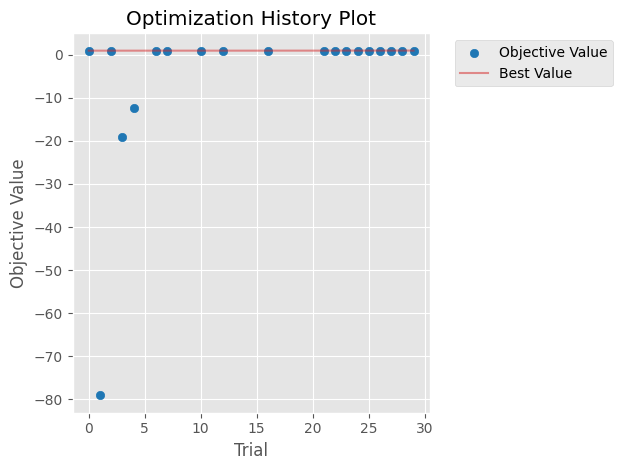

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56389/2314690326.py:170: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = plot_param_importances(study);    plt.tight_layout(); plt.show()


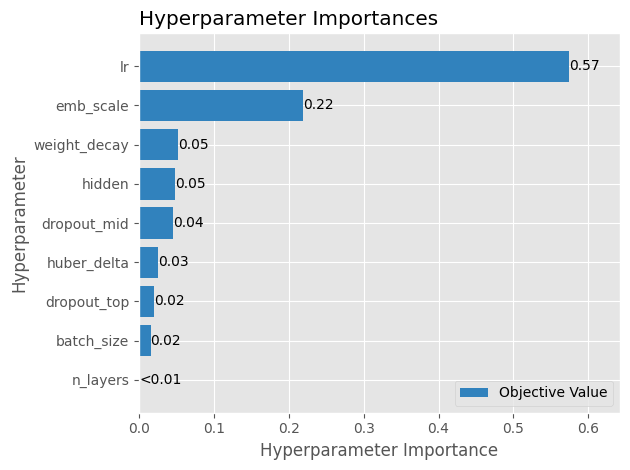

In [12]:
# ─────────────────────────────────────────────────────────────
# Optuna hyperparameter tuning for TaxNetFull.
# Uses an inner train/val split carved from X_train only — the test
# set stays untouched until the final retrain/evaluation below.
# Pruning kills unpromising trials after ~10 epochs.
# ─────────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Inner train/val split (15% val, different seed from test split) ──
rng = np.random.default_rng(7)
perm = rng.permutation(len(X_train))
cut  = int(0.85 * len(X_train))
idx_i, idx_v = perm[:cut], perm[cut:]

Xc_i = Xc_tr[idx_i]; Xk_i = Xk_tr[idx_i]; y_i = y_tr[idx_i]
Xc_v = Xc_tr[idx_v]; Xk_v = Xk_tr[idx_v]; y_v = y_tr[idx_v]
print(f"Inner split — train: {len(idx_i):,}   val: {len(idx_v):,}")

# ── Flexible model constructor ───────────────────────────────
def emb_dim_for(card, scale=1.0):
    return max(2, min(50, round(scale * 1.6 * card ** 0.56)))

class TaxNetTunable(nn.Module):
    def __init__(self, cardinalities, cont_dim, hidden, n_layers,
                 dropout_top, dropout_mid, emb_scale):
        super().__init__()
        self.cat_names = list(cardinalities.keys())
        self.embeddings = nn.ModuleDict({
            str(n): nn.Embedding(int(c), emb_dim_for(int(c), emb_scale))
            for n, c in cardinalities.items()
        })
        emb_total = sum(e.embedding_dim for e in self.embeddings.values())
        self.cont_bn = nn.BatchNorm1d(cont_dim)

        dims = [emb_total + cont_dim] + \
               [max(32, hidden // (2 ** i)) for i in range(n_layers)]
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                nn.Linear(dims[i], dims[i + 1]),
                nn.BatchNorm1d(dims[i + 1]),
                nn.GELU(),
                nn.Dropout(dropout_top if i == 0 else dropout_mid),
            ]
        layers.append(nn.Linear(dims[-1], 1))
        self.head = nn.Sequential(*layers)

    def forward(self, x_cont, x_cat):
        embs = [self.embeddings[str(n)](x_cat[:, i])
                for i, n in enumerate(self.cat_names)]
        return self.head(torch.cat([torch.cat(embs, dim=1),
                                    self.cont_bn(x_cont)], dim=1)).squeeze(1)

# ── Training function used by both Optuna and the final retrain ──
def train_taxnet(params, Xc_tr_, Xk_tr_, y_tr_, Xc_v_, Xk_v_, y_v_,
                 epochs, trial=None, verbose=False):
    model = TaxNetTunable(
        cardinalities, cont_dim=len(cont_cols),
        hidden=params['hidden'], n_layers=params['n_layers'],
        dropout_top=params['dropout_top'], dropout_mid=params['dropout_mid'],
        emb_scale=params['emb_scale'],
    ).to(device)

    loader = DataLoader(
        TensorDataset(Xc_tr_, Xk_tr_, y_tr_),
        batch_size=params['batch_size'], shuffle=True,
        num_workers=0, pin_memory=False)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=params['lr'], total_steps=epochs * len(loader),
        pct_start=0.1, anneal_strategy='cos')
    criterion = nn.HuberLoss(delta=params['huber_delta'])

    best_val_r2 = -np.inf
    y_v_np = y_v_.cpu().numpy()

    for epoch in range(1, epochs + 1):
        model.train()
        for x_c, x_k, y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model(x_c, x_k), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(Xc_v_, Xk_v_).cpu().numpy()
        val_r2 = r2_score(y_v_np, val_pred)
        best_val_r2 = max(best_val_r2, val_r2)

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"    epoch {epoch:>3}  val R²(log)={val_r2:.4f}  best={best_val_r2:.4f}")

        if trial is not None:
            trial.report(val_r2, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return best_val_r2, model

# ── Objective ────────────────────────────────────────────────
TUNE_EPOCHS = 40

def objective(trial):
    params = {
        'hidden':       trial.suggest_categorical('hidden', [128, 256, 384, 512]),
        'n_layers':     trial.suggest_int('n_layers', 2, 4),
        'dropout_top':  trial.suggest_float('dropout_top', 0.10, 0.50),
        'dropout_mid':  trial.suggest_float('dropout_mid', 0.05, 0.30),
        'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        'batch_size':   trial.suggest_categorical('batch_size', [2048, 4096, 8192]),
        'huber_delta':  trial.suggest_float('huber_delta', 0.3, 1.0),
        'emb_scale':    trial.suggest_float('emb_scale', 0.5, 2.0),
    }
    best_val, _ = train_taxnet(
        params, Xc_i, Xk_i, y_i, Xc_v, Xk_v, y_v,
        epochs=TUNE_EPOCHS, trial=trial)
    return best_val

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5))

t0 = time.time()
study.optimize(objective, n_trials=30, show_progress_bar=True)
torch.mps.synchronize()
print(f"\nTuning done in {(time.time()-t0)/60:.1f} min")

print(f"\nBest val R²(log): {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ── Retrain best config on full X_train, evaluate on X_test ──
print("\nRetraining best config on full train set...")
best_params = study.best_params

best_val_r2, nn_model = train_taxnet(
    best_params, Xc_tr, Xk_tr, y_tr, Xc_te, Xk_te, y_te,
    epochs=100, verbose=True)

if 'LUC' in nn_model.embeddings:
    nn_model.emb = nn_model.embeddings['LUC']

# Final test evaluation
nn_model.eval()
with torch.no_grad():
    preds_log = nn_model(Xc_te, Xk_te).cpu().numpy()
preds_orig  = np.expm1(preds_log)
y_true_orig = np.asarray(y_test)

print("\nTuned TaxNet — held-out test")
print(f"  R²(log):  {r2_score(y_te_np,  preds_log):.4f}")
print(f"  R²(orig): {r2_score(y_true_orig, preds_orig):.4f}")
print(f"  MAE:      {mean_absolute_error(y_true_orig, preds_orig):,.0f}")
print(f"  RMSE:     {root_mean_squared_error(y_true_orig, preds_orig):,.0f}")

# Optuna diagnostic plots
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history, plot_param_importances)
    fig1 = plot_optimization_history(study); plt.tight_layout(); plt.show()
    fig2 = plot_param_importances(study);    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"(skipping Optuna plots: {e})")